# 💊 Bahaa Pharmacy — Profitability & Restock Analysis
## Report: Profit per Item (Sales & Invoices)
### Period: January – April 2026

This notebook performs a comprehensive analysis of pharmacy sales data exported 
from Dawatk (Odoo) as `report.profit.item.details.xlsx`.

**Goals:**
1. Clean and prepare the raw data for analysis
2. Identify the most profitable products over the analysis period
3. Build a data-driven restock recommendation list for the next 3 months

---
*Built cell by cell — Dr. Bahaa Pharmacy, Dirout, Egypt*

## Step 1: Import Libraries & Load Data

We begin by importing the essential Python libraries for data analysis and visualization,
then loading the raw Excel export from Dawatk directly into a pandas DataFrame.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Load data ──────────────────────────────────────────────────────────────
FILE = "/home/pharmacy/Januray_April_2026_Pharmacy_Bahaa_Analysis/Datasets/الربح لكل عنصر لنقط البيع و الفواتير (report.profit.item.details).xlsx"

df_raw = pd.read_excel(FILE, sheet_name="Sheet1")

print(f"✅ Loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
df_raw.head(3)

✅ Loaded: 1,368 rows × 22 columns


,باركود,المنتج,المادة الفعالة,المستخدم,البائع,الوكيل,ضرائب,الكمية الفعلية,كمية المخزون الآمنه,الموقع,...,المجموع الفرعي,خصم,التكلفة,الربح,(%) الربح,هامش الربح (٪),رقم المعاملة,تاريخ المعاملة,الحالة,نوع
0,6.285147e+12,[70967 ] ديفيدو 75 ملجم 30 كبسولة (Unit),NaN,Bahaa Mohammed Elkady Abd Eltawab Siddeek,Bahaa Mohammed Elkady Abd Eltawab Siddeek,تابوك,0 Sales,2,0,BAHAA/Stock,...,47.0,0.0,33.75,13.25,28.191,39.259,طلب 00422-001-0006,2026-04-29 22:37:51,تم الإعتماد,طلبات نقطة البيع
1,6.285147e+12,[70967 ] ديفيدو 75 ملجم 30 كبسولة (Unit),NaN,Bahaa Mohammed Elkady Abd Eltawab Siddeek,Bahaa Mohammed Elkady Abd Eltawab Siddeek,تابوك,0 Sales,2,0,BAHAA/Stock,...,47.0,0.0,33.75,13.25,28.191,39.259,طلب 00422-001-0006,2026-04-29 22:37:51,تم الإعتماد,طلبات نقطة البيع
2,6.222548e+12,[71447 ] تروسولي إستحلاب 350 قطعة (Unit),NaN,Bahaa Mohammed Elkady Abd Eltawab Siddeek,Bahaa Mohammed Elkady Abd Eltawab Siddeek,GNC,0 Sales,285,0,BAHAA/Stock,...,5.0,0.0,2.50,2.50,50.000,100.000,طلب 00422-001-0005,2026-04-29 20:36:10,تم الإعتماد,طلبات نقطة البيع


## Step 2: Rename Columns & Initial Inspection

The raw file contains Arabic column headers exported from Dawatk.
We rename them to clean English equivalents for easier programmatic access,
then inspect data types and missing values.

In [5]:
# ── Rename columns ──────────────────────────────────────────────────────────
COLUMNS = {
    df_raw.columns[0]:  'barcode',
    df_raw.columns[1]:  'product',
    df_raw.columns[2]:  'active_ingredient',
    df_raw.columns[3]:  'user',
    df_raw.columns[4]:  'vendor',
    df_raw.columns[5]:  'agent',
    df_raw.columns[6]:  'tax_group',
    df_raw.columns[7]:  'qty_actual',
    df_raw.columns[8]:  'qty_safe_stock',
    df_raw.columns[9]:  'location',
    df_raw.columns[10]: 'qty_sold',
    df_raw.columns[11]: 'subtotal_pretax',
    df_raw.columns[12]: 'subtotal',
    df_raw.columns[13]: 'discount',
    df_raw.columns[14]: 'cost',
    df_raw.columns[15]: 'profit',
    df_raw.columns[16]: 'profit_pct',
    df_raw.columns[17]: 'margin_pct',
    df_raw.columns[18]: 'transaction_ref',
    df_raw.columns[19]: 'transaction_date',
    df_raw.columns[20]: 'status',
    df_raw.columns[21]: 'type',
}

df = df_raw.rename(columns=COLUMNS).copy()

# ── Quick inspection ────────────────────────────────────────────────────────
print("── Column types ──────────────────────────────────────")
print(df.dtypes)
print(f"\n── Missing values ────────────────────────────────────")
print(df.isnull().sum())

── Column types ──────────────────────────────────────
barcode                     float64
product                         str
active_ingredient               str
user                            str
vendor                          str
agent                           str
tax_group                       str
qty_actual                    int64
qty_safe_stock                int64
location                        str
qty_sold                      int64
subtotal_pretax             float64
subtotal                    float64
discount                    float64
cost                        float64
profit                      float64
profit_pct                  float64
margin_pct                  float64
transaction_ref                 str
transaction_date     datetime64[us]
status                          str
type                            str
dtype: object

── Missing values ────────────────────────────────────
barcode              321
product                0
active_ingredient    874
user    

## Step 3: Clean & Filter Data

We perform the following cleaning steps:
- Drop rows where the product name is missing (empty/summary rows from Dawatk export)
- Keep only confirmed sales (`status == 'تم الاعتماد'` and `type == 'طلبات نقطة البيع'`)
- Extract `month` and `date` from `transaction_date` for time-based analysis
- Reset the index for a clean working DataFrame

In [8]:
# ── Drop rows with no product name ─────────────────────────────────────────
df = df_raw.rename(columns=COLUMNS).copy()
df = df[df['product'].notna()].copy()

# ── Trim whitespace from string columns ────────────────────────────────────
df['status'] = df['status'].str.strip()
df['type']   = df['type'].str.strip()

# ── Keep only confirmed POS sales ──────────────────────────────────────────
df = df[
    (df['status'] == 'تم الإعتماد') &
    (df['type']   == 'طلبات نقطة البيع')
].copy()

# ── Extract time features ───────────────────────────────────────────────────
df['month']      = df['transaction_date'].dt.month
df['month_name'] = df['transaction_date'].dt.strftime('%B')
df['date']       = df['transaction_date'].dt.date

df = df.reset_index(drop=True)

print(f"✅ Clean dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\n── Status values  : {df['status'].unique()}")
print(f"── Type values    : {df['type'].unique()}")
print(f"── Month range    : {df['month_name'].unique()}")
print(f"── Date range     : {df['date'].min()}  →  {df['date'].max()}")

✅ Clean dataset: 1,318 rows × 25 columns

── Status values  : <ArrowStringArray>
['تم الإعتماد']
Length: 1, dtype: str
── Type values    : <ArrowStringArray>
['طلبات نقطة البيع']
Length: 1, dtype: str
── Month range    : <ArrowStringArray>
['April', 'March', 'February', 'January']
Length: 4, dtype: str
── Date range     : 2026-01-01  →  2026-04-29


## Step 4: Product-Level Aggregation

We group all transactions by product to compute key performance metrics per item:
- Total quantity sold
- Total revenue (subtotal)
- Total cost
- Total profit
- Average profit margin %

This aggregated table is the foundation for all profitability analysis and 
restock recommendations that follow.

In [9]:
# ── Aggregate by product ────────────────────────────────────────────────────
product_df = (
    df.groupby('product', as_index=False)
    .agg(
        qty_sold      = ('qty_sold',   'sum'),
        total_revenue = ('subtotal',   'sum'),
        total_cost    = ('cost',       'sum'),
        total_profit  = ('profit',     'sum'),
        avg_margin    = ('margin_pct', 'mean'),
        transactions  = ('transaction_ref', 'count'),
    )
    .sort_values('total_profit', ascending=False)
    .reset_index(drop=True)
)

# ── Add profit rank ─────────────────────────────────────────────────────────
product_df['rank'] = product_df.index + 1

print(f"✅ Unique products: {len(product_df)}")
print(f"\n── Top 5 most profitable products ────────────────────")
print(product_df[['rank','product','qty_sold','total_profit','avg_margin']].head())

✅ Unique products: 477

── Top 5 most profitable products ────────────────────
   rank                                   product  qty_sold  total_profit  \
0     1          [71094] ماستر 24 قرص للمضغ (Box)        13        435.96   
1     2            [71085] روني ماس شراب 120 مللي        24        416.78   
2     3  إنترافيتو 20 كبسولة جيلاتينية صلبة (Box)         4        268.41   
3     4           [71471 ] جوينتنال 30 قرص (Unit)         4        246.17   
4     5                بيبرا 20 مجم 28 قرص (Unit)        17        222.41   

   avg_margin  
0   28.705000  
1   33.077625  
2   24.312500  
3   28.991250  
4   34.321615  


## Step 5: ABC Classification

ABC analysis classifies products by their contribution to total profit:

| Class | Cumulative Profit Share | Strategy |
|-------|------------------------|----------|
| A     | 0% → 70%               | High priority — always in stock |
| B     | 70% → 90%              | Medium priority — monitor closely |
| C     | 90% → 100%             | Low priority — stock minimally |

This helps us focus restock budget on the products that drive the most value.

In [10]:
# ── Compute cumulative profit share ─────────────────────────────────────────
total_profit = product_df['total_profit'].sum()

product_df['profit_share_pct']  = product_df['total_profit'] / total_profit * 100
product_df['cumulative_pct']    = product_df['profit_share_pct'].cumsum()

# ── Assign ABC class ────────────────────────────────────────────────────────
def assign_abc(cum_pct):
    if cum_pct <= 70:  return 'A'
    elif cum_pct <= 90: return 'B'
    else:               return 'C'

product_df['abc'] = product_df['cumulative_pct'].apply(assign_abc)

# ── Summary ─────────────────────────────────────────────────────────────────
summary = product_df.groupby('abc', as_index=False).agg(
    products      = ('product',      'count'),
    total_profit  = ('total_profit', 'sum'),
    profit_share  = ('profit_share_pct', 'sum'),
)

print("── ABC Classification Summary ─────────────────────────")
print(summary.to_string(index=False))
print(f"\n── Total profit across all products: {total_profit:,.2f} EGP")

── ABC Classification Summary ─────────────────────────
abc  products  total_profit  profit_share
  A       145       9865.42     69.844423
  B       145       2842.15     20.121630
  C       187       1417.28     10.033947

── Total profit across all products: 14,124.85 EGP


## Step 6: Visualizations

Four charts to understand profitability patterns:
1. **Top 20 Most Profitable Products** — horizontal bar chart
2. **ABC Class Distribution** — pie chart (products count & profit share)
3. **Monthly Profit Trend** — line chart across Jan–Apr
4. **Profit Margin Distribution** — histogram by ABC class

In [12]:
import subprocess
subprocess.run(['pip', 'install', 'arabic-reshaper', 'python-bidi'], check=True)
print("✅ Done")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [arabic-reshaper]
✅ Done


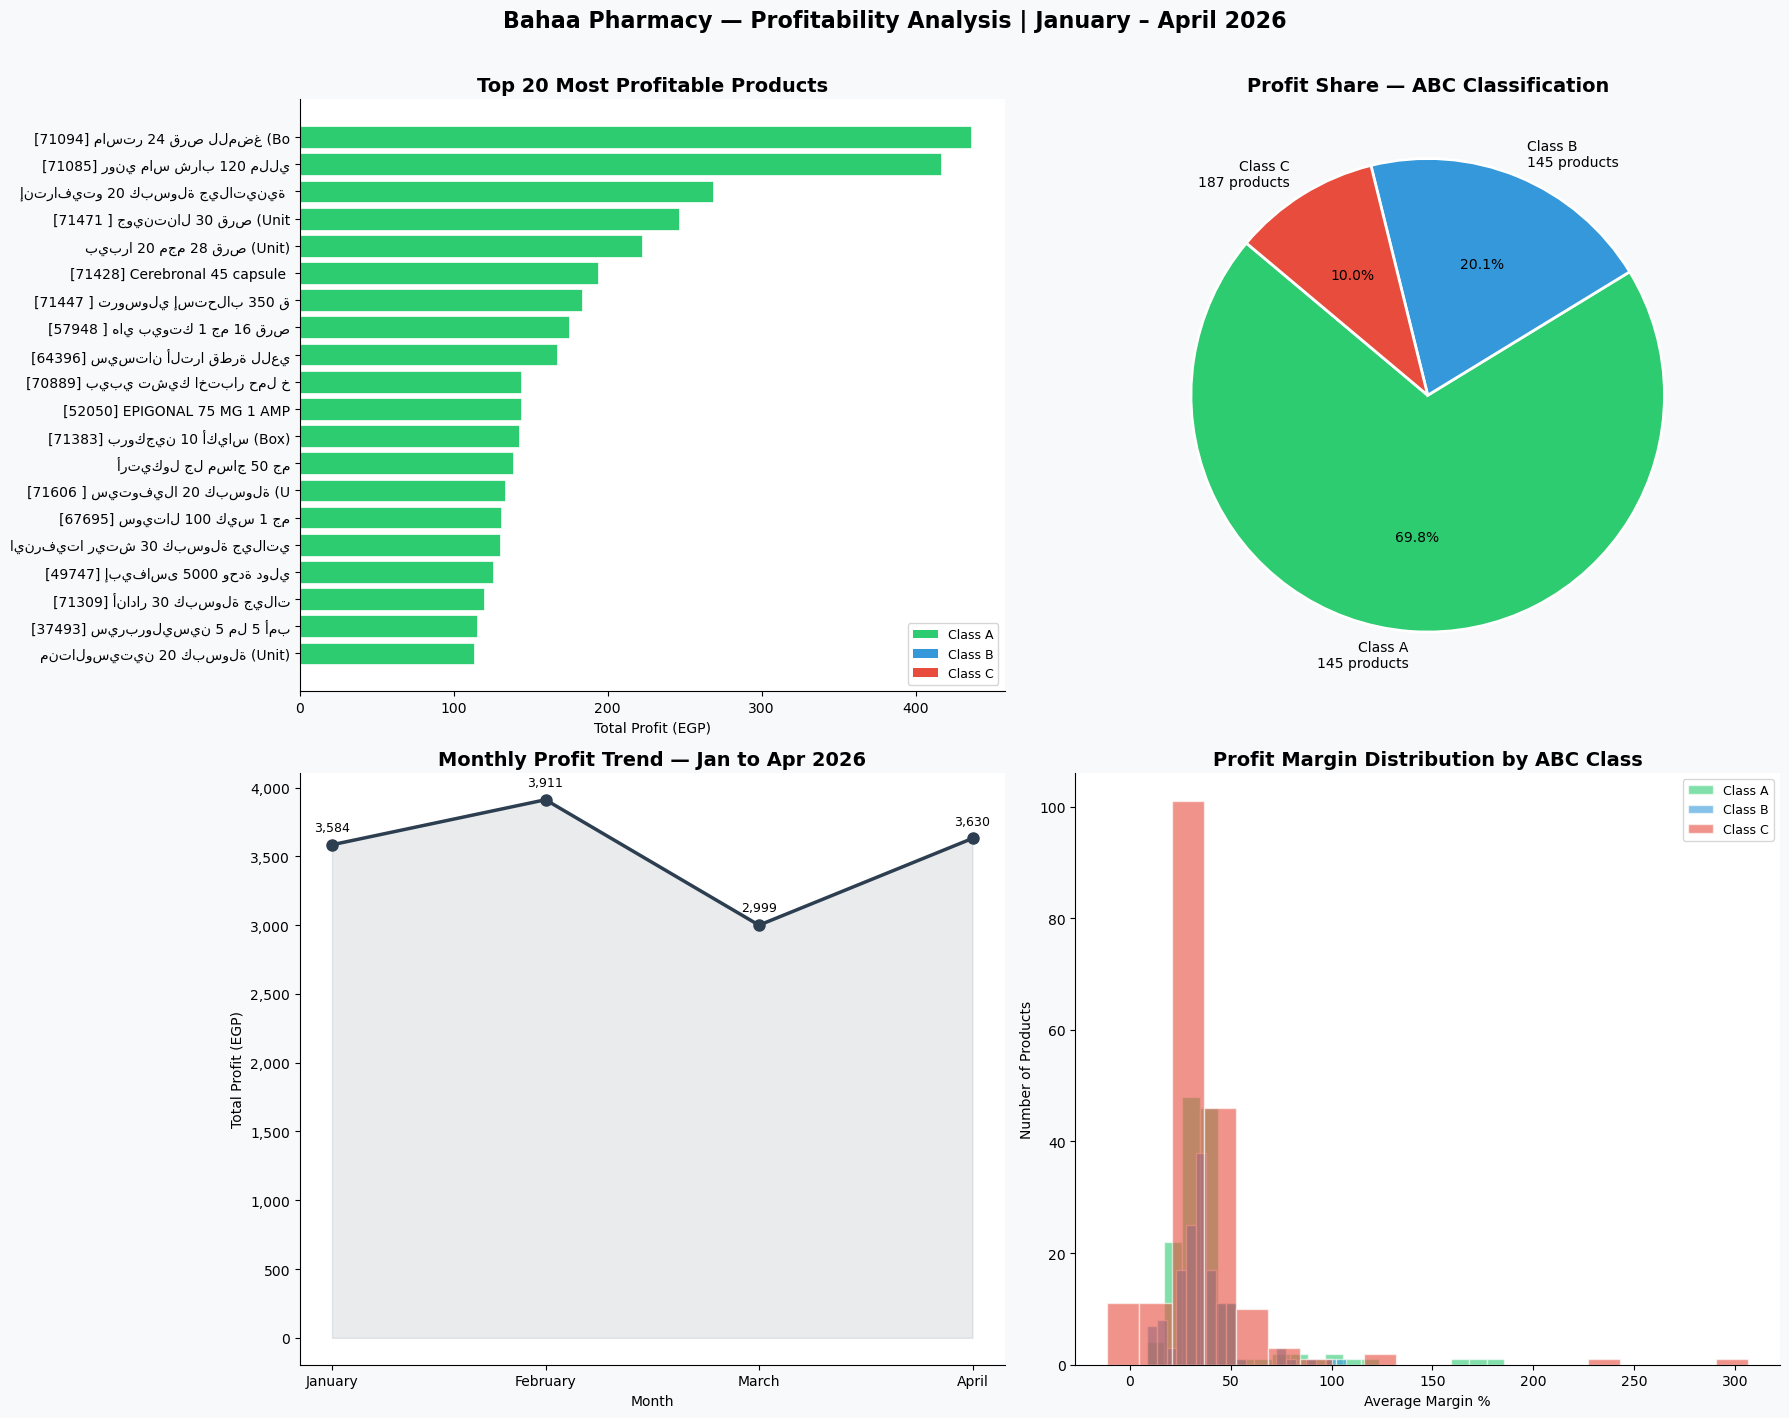

✅ Dashboard saved.


In [14]:
import arabic_reshaper
from bidi.algorithm import get_display

# ── Global style ────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':      'DejaVu Sans',
    'figure.facecolor': '#F8F9FA',
    'axes.facecolor':   '#FFFFFF',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

PALETTE = {'A': '#2ECC71', 'B': '#3498DB', 'C': '#E74C3C'}
FIG_TITLE_SIZE = 14

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Bahaa Pharmacy — Profitability Analysis | January – April 2026',
             fontsize=16, fontweight='bold', y=1.01)

# ── Chart 1: Top 20 Most Profitable Products ────────────────────────────────
ax1 = axes[0, 0]
top20 = product_df.head(20).copy()

# Shorten product names: keep first 30 chars
top20['label'] = top20['product'].str.slice(0, 30)
colors = [PALETTE[c] for c in top20['abc']]

ax1.barh(top20['label'], top20['total_profit'],
         color=colors, edgecolor='white', linewidth=0.5)
ax1.invert_yaxis()
ax1.set_xlabel('Total Profit (EGP)', fontsize=10)
ax1.set_title('Top 20 Most Profitable Products', fontsize=FIG_TITLE_SIZE, fontweight='bold')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
from matplotlib.patches import Patch
legend_els = [Patch(facecolor=PALETTE[c], label=f'Class {c}') for c in 'ABC']
ax1.legend(handles=legend_els, loc='lower right', fontsize=9)

# ── Chart 2: ABC Pie Chart ───────────────────────────────────────────────────
ax2 = axes[0, 1]
pie_data = summary.set_index('abc')
ax2.pie(
    pie_data['total_profit'],
    labels=[f"Class {i}\n{pie_data.loc[i,'products']} products" for i in pie_data.index],
    colors=[PALETTE[i] for i in pie_data.index],
    autopct='%1.1f%%', startangle=140,
    textprops={'fontsize': 10},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
ax2.set_title('Profit Share — ABC Classification', fontsize=FIG_TITLE_SIZE, fontweight='bold')

# ── Chart 3: Monthly Profit Trend ───────────────────────────────────────────
ax3 = axes[1, 0]
monthly = (
    df.groupby('month_name')['profit']
    .sum()
    .reindex(['January', 'February', 'March', 'April'])
    .reset_index()
)
ax3.plot(monthly['month_name'], monthly['profit'],
         marker='o', linewidth=2.5, color='#2C3E50', markersize=8)
ax3.fill_between(monthly['month_name'], monthly['profit'],
                 alpha=0.1, color='#2C3E50')
for _, row in monthly.iterrows():
    ax3.annotate(f"{row['profit']:,.0f}",
                 (row['month_name'], row['profit']),
                 textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9)
ax3.set_xlabel('Month', fontsize=10)
ax3.set_ylabel('Total Profit (EGP)', fontsize=10)
ax3.set_title('Monthly Profit Trend — Jan to Apr 2026', fontsize=FIG_TITLE_SIZE, fontweight='bold')
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# ── Chart 4: Margin Distribution by ABC Class ───────────────────────────────
ax4 = axes[1, 1]
for cls in ['A', 'B', 'C']:
    subset = product_df[product_df['abc'] == cls]['avg_margin']
    ax4.hist(subset, bins=20, alpha=0.6, color=PALETTE[cls],
             label=f'Class {cls}', edgecolor='white')
ax4.set_xlabel('Average Margin %', fontsize=10)
ax4.set_ylabel('Number of Products', fontsize=10)
ax4.set_title('Profit Margin Distribution by ABC Class', fontsize=FIG_TITLE_SIZE, fontweight='bold')
ax4.legend(fontsize=9)

plt.tight_layout()
plt.savefig('profitability_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dashboard saved.")

## Step 7: Restock Recommendation Engine

We build a data-driven restock list for the next 3 months based on:

- **Monthly sales velocity**: average units sold per month per product
- **Projected 3-month demand**: velocity × 3
- **ABC priority class**: A products get a 20% safety buffer, B gets 10%, C gets 0%
- **Focus**: Only Class A and B products are recommended for active restocking

The result is a prioritized purchase order list sorted by total profit contribution.

In [17]:
# ── Monthly sales velocity per product ─────────────────────────────────────
n_months = df['month'].nunique()  # = 4

restock = product_df[product_df['abc'].isin(['A', 'B'])].copy()

restock['monthly_velocity']   = restock['qty_sold'] / n_months
restock['projected_3m_demand'] = restock['monthly_velocity'] * 3

# ── Safety buffer by ABC class ──────────────────────────────────────────────
import numpy as np

buffer = {'A': 1.20, 'B': 1.10}
restock['safety_multiplier']   = restock['abc'].map(buffer)
restock['recommended_qty']     = np.ceil(
    restock['projected_3m_demand'] * restock['safety_multiplier']
).astype(int)

# ── Estimated restock cost ──────────────────────────────────────────────────
restock['avg_unit_cost'] = restock['total_cost'] / restock['qty_sold']
restock['estimated_cost'] = (restock['recommended_qty'] * restock['avg_unit_cost']).round(2)

# ── Final restock table ─────────────────────────────────────────────────────
restock_final = restock[[
    'rank', 'abc', 'product', 'qty_sold',
    'monthly_velocity', 'recommended_qty',
    'avg_unit_cost', 'estimated_cost',
    'total_profit', 'avg_margin'
]].sort_values(['abc', 'total_profit'], ascending=[True, False]).reset_index(drop=True)

restock_final['monthly_velocity'] = restock_final['monthly_velocity'].round(1)
restock_final['avg_unit_cost']    = restock_final['avg_unit_cost'].round(2)
restock_final['avg_margin']       = restock_final['avg_margin'].round(1)

print(f"✅ Restock list: {len(restock_final)} products")
print(f"   Class A: {len(restock_final[restock_final['abc']=='A'])} products")
print(f"   Class B: {len(restock_final[restock_final['abc']=='B'])} products")
print(f"\n── Estimated total restock cost: {restock_final['estimated_cost'].sum():,.2f} EGP")
print(f"\n── Top 10 priority restock items ──────────────────────")
print(restock_final.head(10).to_string(index=False))

✅ Restock list: 290 products
   Class A: 145 products
   Class B: 145 products

── Estimated total restock cost: 36,662.45 EGP

── Top 10 priority restock items ──────────────────────
 rank abc                                  product  qty_sold  monthly_velocity  recommended_qty  avg_unit_cost  estimated_cost  total_profit  avg_margin
    1   A         [71094] ماستر 24 قرص للمضغ (Box)        13               3.2               12         101.25         1215.00        435.96        28.7
    2   A           [71085] روني ماس شراب 120 مللي        24               6.0               22          52.50         1155.00        416.78        33.1
    3   A إنترافيتو 20 كبسولة جيلاتينية صلبة (Box)         4               1.0                4         276.00         1104.00        268.41        24.3
    4   A          [71471 ] جوينتنال 30 قرص (Unit)         4               1.0                4         212.28          849.12        246.17        29.0
    5   A               بيبرا 20 مجم 28 قرص (Unit) 

## Step 8: Export Restock List to Excel

We export the full prioritized restock recommendation list to a formatted Excel file,
ready to use as a purchase order reference for the next 3 months.

In [19]:
import subprocess
subprocess.run(['pip', 'install', 'xlsxwriter'], check=True)
print("✅ Done")

✅ Done


In [20]:
output_path = "/home/pharmacy/Januray_April_2026_Pharmacy_Bahaa_Analysis/Restock_Recommendation_Q2_2026.xlsx"

# ── Prepare export dataframe ────────────────────────────────────────────────
export_df = restock_final[[
    'rank', 'abc', 'product', 'qty_sold',
    'monthly_velocity', 'recommended_qty',
    'avg_unit_cost', 'estimated_cost',
    'total_profit', 'avg_margin'
]].copy()

export_df.columns = [
    'Profit Rank', 'ABC Class', 'Product', 'Total Sold (4 Months)',
    'Monthly Velocity', 'Recommended Qty (3M)',
    'Avg Unit Cost (EGP)', 'Estimated Restock Cost (EGP)',
    'Total Profit (EGP)', 'Avg Margin %'
]

# ── Write to Excel with formatting ──────────────────────────────────────────
with pd.ExcelWriter(output_path, engine='xlsxwriter') as writer:
    export_df.to_excel(writer, sheet_name='Restock Q2 2026', index=False)

    wb  = writer.book
    ws  = writer.sheets['Restock Q2 2026']

    # Formats
    header_fmt = wb.add_format({'bold': True, 'bg_color': '#2C3E50', 'font_color': '#FFFFFF', 'border': 1, 'align': 'center'})
    class_a    = wb.add_format({'bg_color': '#D5F5E3', 'border': 1})
    class_b    = wb.add_format({'bg_color': '#D6EAF8', 'border': 1})
    money_fmt  = wb.add_format({'num_format': '#,##0.00', 'border': 1})
    int_fmt    = wb.add_format({'num_format': '#,##0',   'border': 1})
    pct_fmt    = wb.add_format({'num_format': '0.0"%"',  'border': 1})

    # Header row
    for col_num, col_name in enumerate(export_df.columns):
        ws.write(0, col_num, col_name, header_fmt)

    # Column widths
    ws.set_column('A:A', 10)   # Rank
    ws.set_column('B:B', 10)   # ABC
    ws.set_column('C:C', 45)   # Product
    ws.set_column('D:D', 18)   # Total Sold
    ws.set_column('E:E', 16)   # Velocity
    ws.set_column('F:F', 20)   # Recommended Qty
    ws.set_column('G:G', 20)   # Unit Cost
    ws.set_column('H:H', 25)   # Estimated Cost
    ws.set_column('I:I', 18)   # Total Profit
    ws.set_column('J:J', 14)   # Margin

    # Data rows with conditional coloring
    for row_num, row in export_df.iterrows():
        fmt = class_a if row['ABC Class'] == 'A' else class_b
        ws.write(row_num + 1, 0, row['Profit Rank'],                    fmt)
        ws.write(row_num + 1, 1, row['ABC Class'],                      fmt)
        ws.write(row_num + 1, 2, row['Product'],                        fmt)
        ws.write(row_num + 1, 3, row['Total Sold (4 Months)'],          int_fmt)
        ws.write(row_num + 1, 4, row['Monthly Velocity'],               money_fmt)
        ws.write(row_num + 1, 5, row['Recommended Qty (3M)'],           int_fmt)
        ws.write(row_num + 1, 6, row['Avg Unit Cost (EGP)'],            money_fmt)
        ws.write(row_num + 1, 7, row['Estimated Restock Cost (EGP)'],   money_fmt)
        ws.write(row_num + 1, 8, row['Total Profit (EGP)'],             money_fmt)
        ws.write(row_num + 1, 9, row['Avg Margin %'],                   pct_fmt)

    # Summary row at the bottom
    last = len(export_df) + 2
    total_fmt = wb.add_format({'bold': True, 'bg_color': '#2C3E50', 'font_color': '#FFFFFF',
                                'num_format': '#,##0.00', 'border': 1})
    ws.write(last, 2, 'TOTAL ESTIMATED RESTOCK COST', total_fmt)
    ws.write(last, 7, export_df['Estimated Restock Cost (EGP)'].sum(), total_fmt)
    ws.write(last, 8, export_df['Total Profit (EGP)'].sum(), total_fmt)

print(f"✅ Restock list exported to:")
print(f"   {output_path}")
print(f"\n── Summary ────────────────────────────────────────────")
print(f"   Total products     : {len(export_df)}")
print(f"   Class A products   : {len(export_df[export_df['ABC Class']=='A'])}")
print(f"   Class B products   : {len(export_df[export_df['ABC Class']=='B'])}")
print(f"   Total restock cost : {export_df['Estimated Restock Cost (EGP)'].sum():,.2f} EGP")
print(f"   Expected profit    : {export_df['Total Profit (EGP)'].sum():,.2f} EGP")

✅ Restock list exported to:
   /home/pharmacy/Januray_April_2026_Pharmacy_Bahaa_Analysis/Restock_Recommendation_Q2_2026.xlsx

── Summary ────────────────────────────────────────────
   Total products     : 290
   Class A products   : 145
   Class B products   : 145
   Total restock cost : 36,662.45 EGP
   Expected profit    : 12,707.57 EGP
